# Fase 3 — Preparación de secuencias y Fase 4 — Modelos de referencia

**Objetivo:** convertir la tabla limpia en el formato que espera una LSTM: un tensor de forma `(muestras, n horas, variables)`. Todo se hace **sin fugas de información**.

Pasos:
1. Variables de entrada (incluida la codificación cíclica).
2. División cronológica en train / validación / test.
3. Normalización con parámetros calculados **solo en train**.
4. Construcción de ventanas de 12, 24 y 48 h.
5. Pruebas automáticas de fuga de información.
6. Modelos de referencia (baselines): la barra mínima que las LSTM deben superar.

El código está en [`src/preparacion.py`](../src/preparacion.py). Este notebook lo usa y verifica.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))
import preparacion as P
from metricas import metricas, metricas_picos
from graficos import aplicar_estilo, AZUL, NARANJA, AQUA, TINTA_2
aplicar_estilo()
FIG = RAIZ / "resultados/figuras"
df = pd.read_parquet(RAIZ / "data/processed/dataset_limpio.parquet")

## 1. Variables de entrada

| Grupo | Variables | Por qué |
|---|---|---|
| Autorregresiva | `demanda` (tratamiento A: `demanda_mw`; B: `demanda_mw_recuperada`) | La demanda pasada es el mejor predictor (ACF lag 1 = 0.88) |
| Exógenas | `temperatura_c`, `humedad_pct`, `radiacion_wm2`, `precio_kwh` | Mostraron relación con la demanda en el EDA |
| Calendario | `hora`, `dia_semana`, `mes` en **seno/coseno**; `fin_semana`, `festivo` | Ciclos diario, semanal y anual |
| Bandera | `flag_exogena_rellenada` | Avisa al modelo que un dato exógeno es el último valor conocido, no una lectura fresca |

**Excluidas:** `viento_kmh` y `precipitacion_mm` (sin información en el EDA; se verifica con una ablación en la Fase 6), `periodo_dia` (redundante con `hora`), `timestamp` (se reemplaza por sus componentes cíclicos) y, sobre todo, **`demanda_objetivo` como entrada**, porque es la respuesta.

### ¿Por qué codificación cíclica?
Si la hora entra como número (0…23), el modelo "ve" que 23 y 0 están a 23 unidades de distancia, aunque en la realidad son horas consecutivas. Al convertirla en un punto sobre un círculo (seno, coseno), las horas vecinas quedan cerca.

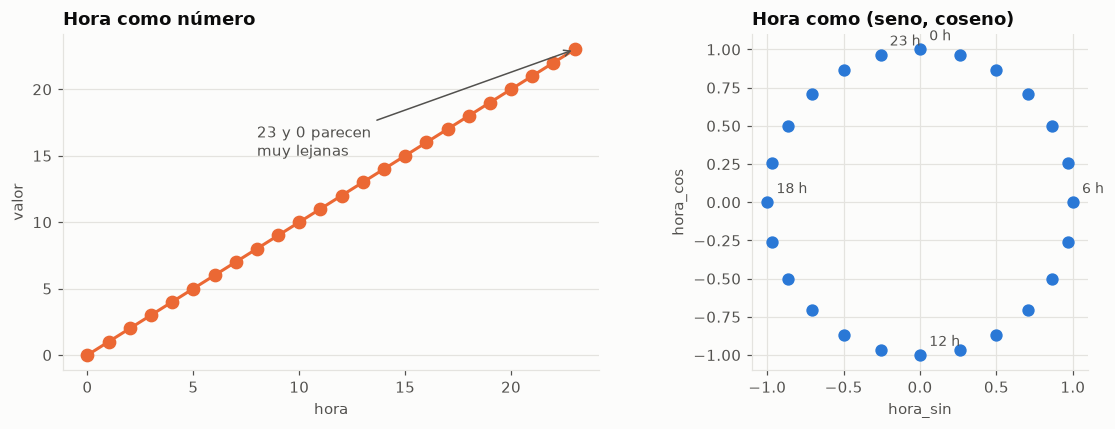

In [2]:
h = np.arange(24)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(h, h, marker="o", color=NARANJA); ax[0].set_title("Hora como número"); ax[0].set_xlabel("hora"); ax[0].set_ylabel("valor")
ax[0].annotate("23 y 0 parecen\nmuy lejanas", (23, 23), xytext=(8, 15), arrowprops={"arrowstyle": "->", "color": TINTA_2}, color=TINTA_2)
s, c = np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24)
ax[1].scatter(s, c, color=AZUL, s=50, zorder=3)
for i in [0, 6, 12, 18, 23]:
    ax[1].annotate(f"{i} h", (s[i], c[i]), xytext=(6, 6), textcoords="offset points", fontsize=9, color=TINTA_2)
ax[1].set_aspect("equal"); ax[1].set_title("Hora como (seno, coseno)"); ax[1].set_xlabel("hora_sin"); ax[1].set_ylabel("hora_cos")
ax[1].grid(True, axis="both")
plt.tight_layout(); plt.savefig(FIG / "03_codificacion_ciclica.png"); plt.show()

## 2. Construcción de ventanas

Una **ventana** de tamaño *n* toma las filas `[t−n+1, …, t]` como entrada, y su salida es `demanda_objetivo(t)`, es decir, la demanda de la hora **t+1**.

```
filas:     t-23  t-22  ...  t-1   t   │  objetivo
entrada:   [ demanda, clima, calendario ... ]    │  demanda(t+1)
```

Una ventana se descarta si cualquiera de sus *n* filas, o su objetivo, tiene NaN. Gracias a la rejilla horaria completa (Fase 1), *n* filas seguidas son *n* horas seguidas.

**División cronológica por la hora del objetivo:**
- Train: objetivos hasta 2026-06-30 23:00
- Validación: 2026-07-01 → 2026-09-30
- Test: 2026-10-01 → 2026-12-31

Una ventana de validación o test puede usar como entrada las últimas horas de train: eso es **pasado**, no futuro. Lo que no se cruza es el **objetivo**.

In [3]:
filas = []
for trat in ("A", "B"):
    for n in P.VENTANAS:
        d = P.preparar(df, n, trat)
        filas.append({"tratamiento": trat, "ventana": n, "forma X train": d["train"]["X"].shape,
                      **{f"muestras {s}": len(d[s]["y"]) for s in ("train", "val", "test")}})
tabla_muestras = pd.DataFrame(filas)
tabla_muestras

,tratamiento,ventana,forma X train,muestras train,muestras val,muestras test
0,A,12,"(12720, 12, 14)",12720,2136,2182
1,A,24,"(12336, 24, 14)",12336,2064,2158
2,A,48,"(11568, 48, 14)",11568,1920,2110
3,B,12,"(13092, 12, 14)",13092,2208,2208
4,B,24,"(13080, 24, 14)",13080,2208,2208
5,B,48,"(13056, 48, 14)",13056,2208,2208


**Lectura:**
- Forma `(muestras, n, 14)`: 14 variables por hora.
- **Tratamiento B** (recuperar la demanda desde la otra medición) conserva prácticamente todas las muestras.
- **Tratamiento A** (descartar ventanas con demanda en conflicto) pierde más cuanto más larga es la ventana: un solo valor anulado invalida las *n* ventanas que lo contienen.
- Gracias al ffill causal de las exógenas (Fase 1), esa pérdida es pequeña. Sin él, la ventana de 48 h habría perdido ~65 % de los datos.

## 3. Normalización: solo con train

Las LSTM entrenan mejor si las variables tienen escalas comparables (media 0, desviación 1). Si la temperatura va de 5 a 35 y la demanda de 300 a 900, los gradientes estarían dominados por la de mayor escala.

**La regla clave:** la media y la desviación se calculan **solo con datos de entrenamiento** y luego se aplican, tal cual, a validación y test. Si usáramos todo el dataset, el modelo "sabría" de antemano el nivel medio del test. Eso es una fuga, aunque sea sutil.

- Se estandarizan las variables continuas (demanda y exógenas). Las sin/cos y las binarias ya están en [−1, 1].
- *y* tiene su propio escalador, ajustado solo con los objetivos de train. Las métricas se reportan siempre **en MW**, deshaciendo la escala.

In [4]:
d24 = P.preparar(df, 24, "B")
esc = d24["escaladores"]
print("Media y desviación usadas (calculadas en train):")
print(pd.DataFrame({"media": esc.x.mean_, "desv": esc.x.scale_},
                   index=[d24["features"][i] for i in esc.idx]).round(2))
for s in ("train", "val", "test"):
    print(f"y escalada en {s:5s}: media {d24[s]['y'].mean():+.3f}  desv {d24[s]['y'].std():.3f}")

Media y desviación usadas (calculadas en train):
                media    desv
demanda        636.07   98.41
temperatura_c   19.27    5.68
humedad_pct     71.75   14.77
radiacion_wm2  206.06  262.47
precio_kwh      24.67    5.34
y escalada en train: media +0.000  desv 1.000
y escalada en val  : media +0.200  desv 1.033
y escalada en test : media -0.366  desv 0.811


Observa que la *y* de **test** no queda con media 0. Eso es **correcto y esperado**: el test es temporada baja (EDA, sección 7). Si la media quedara exactamente en 0, sería señal de que el escalador vio el test.

## 4. Pruebas automáticas de fuga de información

No basta con "tener cuidado": lo verificamos con código. Si alguna prueba fallara, el notebook se detendría.

In [5]:
for n in P.VENTANAS:
    for trat in ("A", "B"):
        d = P.preparar(df, n, trat)
        # (1) Los splits no se solapan y están en orden
        assert d["train"]["ts_objetivo"].max() < P.INICIO_VAL <= d["val"]["ts_objetivo"].min()
        assert d["val"]["ts_objetivo"].max() < P.INICIO_TEST <= d["test"]["ts_objetivo"].min()
        # (2) La última hora de entrada es la anterior al objetivo (nunca el objetivo mismo)
        e = d["escaladores"]
        ultima = d["test"]["X"][:, -1, 0] * e.x.scale_[0] + e.x.mean_[0]
        assert np.allclose(ultima, d["test"]["demanda_t"], atol=0.05), "la entrada no termina en t"
        # (3) Sin NaN en ninguna ventana
        assert not any(np.isnan(d[s]["X"]).any() for s in ("train", "val", "test"))
        # (4) El escalador de y solo vio train
        assert np.isclose(e.y.mean_[0], d["train"]["y_mw"].mean())
print("✔ Todas las pruebas de fuga pasaron para las 6 configuraciones")

✔ Todas las pruebas de fuga pasaron para las 6 configuraciones


## 5. Conjunto de test común

Cada configuración tiene un número distinto de muestras de test (tabla de arriba). Si cada modelo se evaluara sobre "su" test, las métricas no serían comparables: uno podría tener ventaja solo por evaluarse en horas más fáciles.

**Solución:** todas las comparaciones se hacen sobre las **mismas horas objetivo**: las válidas en *todas* las configuraciones. La más restrictiva es A con 48 h.

In [6]:
comun = set(P.preparar(df, 48, "A")["test"]["ts_objetivo"])
print(f"Horas de test comunes: {len(comun)} de 2208 ({len(comun)/2208:.1%})")

Horas de test comunes: 2110 de 2208 (95.6%)


## 6. Fase 4 — Modelos de referencia (baselines)

Antes de entrenar una red neuronal hay que preguntarse: **¿qué tan bien lo haría un método trivial?** Si la LSTM no lo supera, no aporta nada.

| Baseline | Predicción para t+1 | Idea |
|---|---|---|
| **Persistencia** | demanda(t) | "La próxima hora será igual a esta" |
| **Estacional diaria** | demanda(t+1−24) | "Será igual a la misma hora de ayer" |
| **Estacional semanal** | demanda(t+1−168) | "Será igual a la misma hora de la semana pasada" (ACF lag 168 = 0.92) |
| **Perfil histórico** | media de train para esa hora × tipo de día | "Será la demanda típica de esta hora en un día así" |

In [7]:
base = P.construir_variables(df, "B").set_index("timestamp")
dem = base["demanda_mw_recuperada"]
test = d24["test"]
m = np.isin(test["ts_objetivo"], list(comun))
t_obj = test["ts_objetivo"][m]; y_real = test["y_mw"][m]

perfil = base[base.index < P.INICIO_VAL].groupby(["hora", "fin_semana"])["demanda_objetivo"].mean()
t_prev = t_obj - pd.Timedelta(hours=1)   # fila t, cuyo objetivo es t+1
predicciones = {
    "Persistencia": dem.reindex(t_prev).to_numpy(),
    "Estacional diaria (t−24)": dem.reindex(t_obj - pd.Timedelta(hours=24)).to_numpy(),
    "Estacional semanal (t−168)": dem.reindex(t_obj - pd.Timedelta(hours=168)).to_numpy(),
    "Perfil histórico": perfil.reindex(pd.MultiIndex.from_arrays(
        [t_obj.hour, (t_obj.dayofweek >= 5).astype(int)])).to_numpy(),
}
baselines = pd.DataFrame({k: {**metricas(y_real, v), **metricas_picos(y_real, v)} for k, v in predicciones.items()}).T
baselines.to_csv(RAIZ / "resultados/baselines.csv")
baselines.round(3)

,MAE,MSE,RMSE,MAPE,R2,MAE_picos,sesgo_picos
Persistencia,35.159,1943.156,44.081,5.958,0.688,40.013,-32.541
Estacional diaria (t−24),51.539,4732.198,68.791,8.912,0.240,50.818,-43.994
Estacional semanal (t−168),28.383,1386.900,37.241,4.868,0.777,24.474,-13.263
Perfil histórico,49.009,3627.059,60.225,8.439,0.417,32.234,20.800


**Lectura:**
- **El mejor baseline es la estacional semanal** (RMSE ≈ 37 MW, R² ≈ 0.78), no la persistencia (RMSE ≈ 44 MW). Es coherente con el ACF: el lag 168 (0.92) es el más alto después del lag 1. La demanda de hoy se parece mucho a la del mismo día y hora de la semana pasada.
- La estacional **diaria** es la peor: compara, por ejemplo, un lunes con un domingo.
- **La barra real que deben superar las LSTM es RMSE ≈ 37 MW.** Es un reto interesante: ninguna ventana del taller (máx. 48 h) alcanza a ver la semana anterior. La LSTM tendrá que combinar la historia reciente con las variables de calendario.
- `sesgo_picos` negativo significa que el método **subestima** los picos. La persistencia lo hace mucho (−33 MW), porque en una rampa de subida siempre llega "una hora tarde".

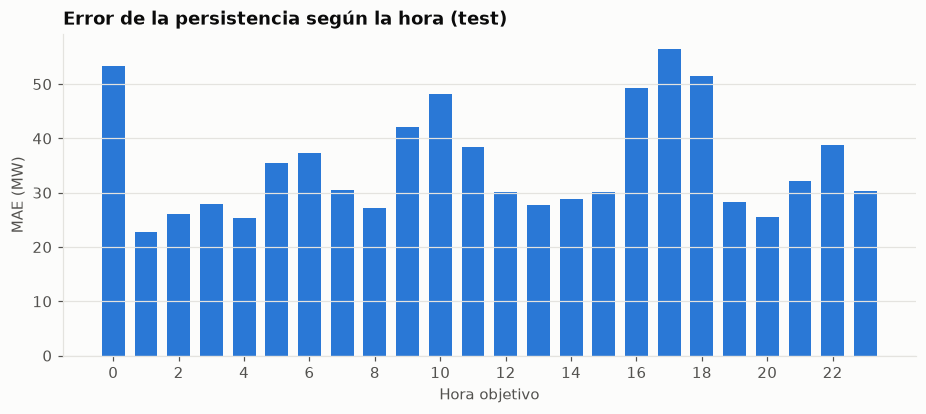

In [8]:
err_pers = np.abs(y_real - predicciones["Persistencia"])
por_hora = pd.Series(err_pers, index=t_obj.hour).groupby(level=0).mean()
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(por_hora.index, por_hora.values, color=AZUL, width=0.7)
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("Hora objetivo"); ax.set_ylabel("MAE (MW)")
ax.set_title("Error de la persistencia según la hora (test)")
plt.savefig(FIG / "04_error_persistencia_por_hora.png"); plt.show()

La persistencia falla sobre todo en las **rampas**: la subida de la tarde (16–19 h) y la bajada de la mañana (8–11 h). Ahí es donde las LSTM, que ven toda la ventana y el calendario, deberían marcar la diferencia.